In [1]:
# Header for the notebook
from datetime import datetime
from IPython.display import display, Markdown

# Get the current date
title = "Internship project"
current_date = datetime.now().strftime("%d %B %Y, %H:%M:%S")
authors = "Ancelin Gely (and Copilot)"

# Insert the date into the notebook
display(Markdown(f"# {title}"))
display(Markdown(f"{current_date}"))
display(Markdown(f"by {authors}"))

# Internship project

30 September 2026, 11:34:04

by Ancelin Gely (and Copilot)

In [2]:
%pip install actipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Import libraries
import pandas as pd
import pandas as pd
import actipy
import actipy.processing as P
import numpy as np

In [4]:
# From "data", import raw_10_30.csv.gz
data = pd.read_csv("data/raw_10_30.csv.gz", header = None)
data.columns = ["x", "y", "z"] # must be lower case letters to use actipy functions

print(data.head())
print(data.columns)
print("The table do not have a time column, but the sampling frequency is 80 Hz, so the next step is to create a time column based on the sampling frequency.")

          x         y         z
0  0.780042 -0.532365  1.368320
1 -2.473200 -0.788042  0.312967
2 -2.387759  2.451502  0.124689
3 -1.046822  0.081710  0.613195
4 -1.158155  0.587271  1.212668
Index(['x', 'y', 'z'], dtype='object')
The table do not have a time column, but the sampling frequency is 80 Hz, so the next step is to create a time column based on the sampling frequency.


In [5]:
# Data description
FS = 80 # Hz
T = 1/FS # Sampling period
duration = len(data) / 80

print("Number of samples:", len(data))
print("Duration:", duration, "seconds")

Number of samples: 300000
Duration: 3750.0 seconds


In [6]:
# Create a time column based on the sampling frequency
data["time"] = pd.date_range(
    start="2026-01-01",
    periods=len(data),
    freq=pd.Timedelta(seconds=1/FS)
)
data["time"] = pd.to_datetime(data["time"])
data = data.set_index("time")

print(data.head())

                                   x         y         z
time                                                    
2026-01-01 00:00:00.000000  0.780042 -0.532365  1.368320
2026-01-01 00:00:00.012500 -2.473200 -0.788042  0.312967
2026-01-01 00:00:00.025000 -2.387759  2.451502  0.124689
2026-01-01 00:00:00.037500 -1.046822  0.081710  0.613195
2026-01-01 00:00:00.050000 -1.158155  0.587271  1.212668


In [7]:
# Calibrate the data using actipy
# Calibration
data_calibrated, info_calib = P.calibrate_gravity(data)

print(info_calib)
print(data_calibrated.head())

{'CalibNumSamples': 0, 'CalibErrorBefore(mg)': nan, 'CalibErrorAfter(mg)': nan, 'CalibOK': 0}
                                   x         y         z
time                                                    
2026-01-01 00:00:00.000000  0.780042 -0.532365  1.368320
2026-01-01 00:00:00.012500 -2.473200 -0.788042  0.312967
2026-01-01 00:00:00.025000 -2.387759  2.451502  0.124689
2026-01-01 00:00:00.037500 -1.046822  0.081710  0.613195
2026-01-01 00:00:00.050000 -1.158155  0.587271  1.212668


c:\Users\gelya\miniconda3\Lib\site-packages\actipy\processing.py:422: UserWarning: Skipping calibration: Insufficient stationary samples: 0 < 50
  warnings.warn(f"Skipping calibration: Insufficient stationary samples: {len(xyz)} < {calib_min_samples}")


# 1. calibration

Skipping calibreation :  Insufficient stationary samples: 0 < 50
So we have to understand why the calibration is not working. The calibration function requires at least 50 stationary samples to perform the calibration. Since we have 0 stationary samples, it means that the data does not contain enough stationary periods for the calibration to be successful.

In [8]:
# check if Standard deviation < 0.015 for 10 seconds (800 samples) to consider the data as stationary
window = 80 * 10  # 800 samples

rolling_std = data[["x", "y", "z"]].rolling(window).std()
stationary = (
    (rolling_std["x"] < 0.015) &
    (rolling_std["y"] < 0.015) &
    (rolling_std["z"] < 0.015)
)

print("Number of stationary samples:", stationary.sum())
print("Approx. stationary time:", stationary.sum() / 80, "seconds")
print("the calibration function requires at least 50 stationary samples to perform the calibration. ")
print("Since we have 0 stationary samples, it means that the data does not contain enough stationary periods for the calibration to be successful.")



Number of stationary samples: 0
Approx. stationary time: 0.0 seconds
the calibration function requires at least 50 stationary samples to perform the calibration. 
Since we have 0 stationary samples, it means that the data does not contain enough stationary periods for the calibration to be successful.


# 2. Compute ENMO for epochs of 10 sec

In [9]:
# ENMO are calculated with the function : ENMO = sqrt(x^2 + y^2 + z^2) - 1g, with negative values set to zero. The ENMO values are then averaged over epochs of 10 seconds.
epoch_length = 10  # seconds

# Vector magnitude (VM) calculation
vm = np.sqrt(
    data["x"]**2 +
    data["y"]**2 +
    data["z"]**2
)

# Subtract 1g and set negative values to zero
enmo = (vm - 1).clip(lower=0)

# Resample ENMO to 10-second epochs and calculate the mean
enmo_10 = enmo.resample(f"{epoch_length}s").mean()

# Results
print(len(enmo_10))
print(enmo_10.describe())

375
count    375.000000
mean       0.649850
std        0.020988
min        0.589383
25%        0.634752
50%        0.650576
75%        0.664212
max        0.723797
dtype: float64


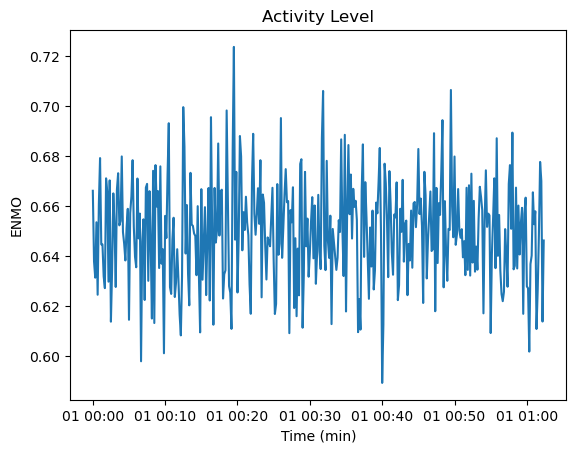

In [10]:
# Plot the ENMO values
import matplotlib.pyplot as plt

plt.plot(enmo_10)
plt.xlabel("Time (min)")
plt.ylabel("ENMO")
plt.title("Activity Level")
# Add a red dot for each value
#for i in range(len(enmo)):
    #plt.plot(enmo.index[i], enmo.iloc[i], 'ro')
plt.show()

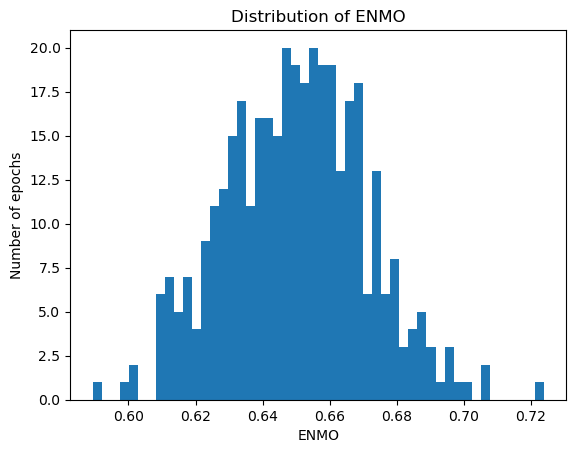

In [11]:
plt.hist(enmo_10, bins=50)
plt.xlabel("ENMO")
plt.ylabel("Number of epochs")
plt.title("Distribution of ENMO")
plt.show()

# Compute MAD


In [12]:
# Calulate the Mean Amplitude Deviation (MAD) for each epoch
# Use the value of the ENMO calculated for each epoch to calculate the MAD for each epoch. 
# The MAD is calculated as the mean of the absolute deviations from the mean of the ENMO values within each epoch. 


# Vector Magnitude
vm = np.sqrt(
    data["x"]**2 +
    data["y"]**2 +
    data["z"]**2
)

# MAD over 10-second epochs
mad_10 = vm.resample(f"{epoch_length}s").apply(
    lambda epoch: np.mean(np.abs(epoch - epoch.mean()))
)

# Results 
print(mad_10.head())
print(len(mad_10))


time
2026-01-01 00:00:00    0.538492
2026-01-01 00:00:10    0.515912
2026-01-01 00:00:20    0.547175
2026-01-01 00:00:30    0.566913
2026-01-01 00:00:40    0.524390
Freq: 10s, dtype: float64
375


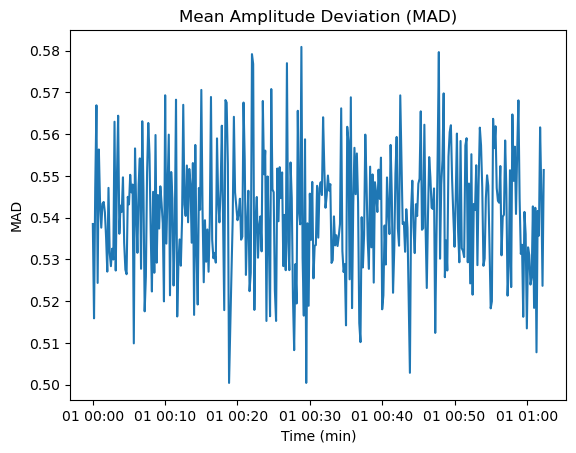

In [13]:
# Plot the MAD values
plt.plot(mad_10)
plt.xlabel("Time (min)")
plt.ylabel("MAD")
plt.title("Mean Amplitude Deviation (MAD)")
plt.show()

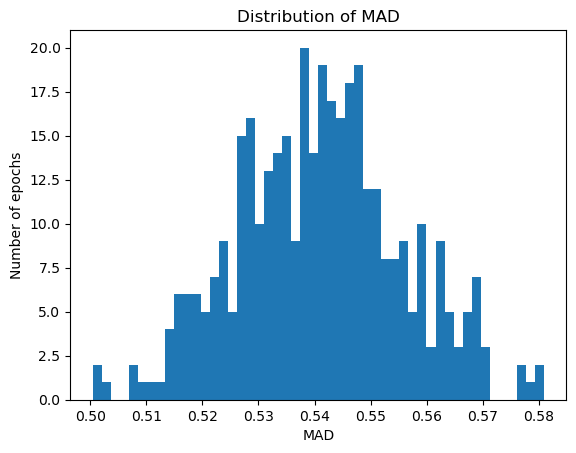

In [14]:
plt.hist(mad_10, bins=50)
plt.xlabel("MAD")
plt.ylabel("Number of epochs")
plt.title("Distribution of MAD")
plt.show()

# Analyze the relationship between ENMO and MAD

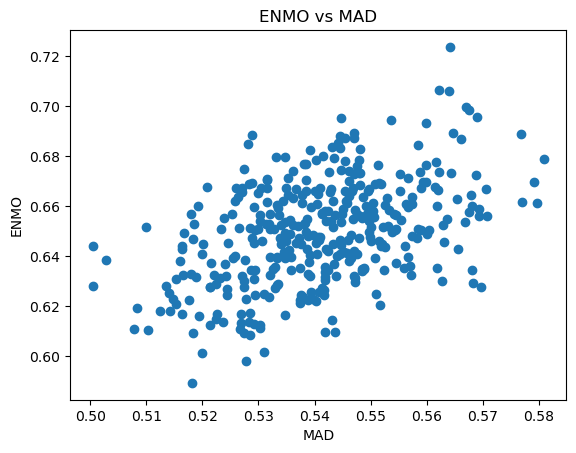

In [15]:
# Plot ENMO as a function of MAD
plt.scatter(mad_10, enmo_10)
plt.xlabel("MAD")
plt.ylabel("ENMO")
plt.title("ENMO vs MAD")
plt.show()

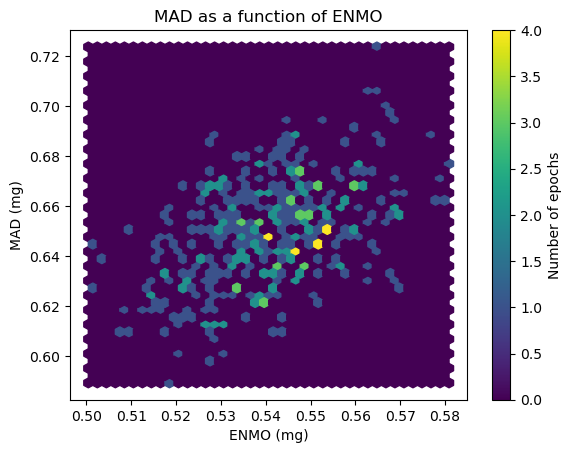

In [16]:
plt.hexbin(mad_10,enmo_10, gridsize=40)
plt.xlabel("ENMO (mg)")
plt.ylabel("MAD (mg)")
plt.title("MAD as a function of ENMO")
plt.colorbar(label="Number of epochs")
plt.show()

# Gradient intensity